In [1]:
import numpy as np
from astropy.io import fits
from astropy import constants
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
from pandas import DataFrame


from pyuvdata.utils.plotting import plot_beam_arrays
from pyuvdata import UVBeam

In [2]:
jmatrix_file = "/Users/bryna/Projects/Physics/data_files/mwa_beams/Jmatrix.fits"
zmatrix_file = "/Users/bryna/Projects/Physics/data_files/mwa_beams/Zmatrix.fits"

In [3]:
dipole_spacing = 1.1    # meters
base_delay_sec = 4.35E-10 #435 picoseconds is base delay length unit [units in seconds]

delays = np.zeros((2, 16), dtype=float)
gains = np.ones((2, 16), dtype=float)


In [4]:
mwa_impedance_freq=np.arange(50,501,dtype=float)*1e6
mwa_impedance = np.array([52.803 + 151.76j,52.446 + 154.04j,52.19 + 157.03j,51.811 + 160.69j,\
51.528 + 164.85j,51.802 + 169.38j,52.157 + 174.17j,52.522 + 179.32j,\
53.377 + 184.66j,54.249 + 189.98j,55.512 + 195.65j,56.949 + 201.94j,\
58.519 + 208.08j,60.179 + 214.4j,62.755 + 220.82j,65.071 + 227.42j,\
67.949 + 234.58j,71.302 + 241.31j,74.795 + 248.26j,78.823 + 255.1j,\
83.465 + 262.45j,88.307 + 268.87j,93.864 + 275.2j,99.639 + 281.3j,\
105.58 + 287.5j,111.82 + 293.16j,118.57 + 298.85j,125.37 + 303.59j,\
132.08 + 308.64j,138.4 + 313.49j,144.44 + 318.07j,150.64 + 323.03j,\
157.06 + 327.82j,163.72 + 332.52j,170.03 + 337.71j,176.67 + 343.27j,\
184.35 + 349.36j,192.29 + 355.09j,200.02 + 360.97j,208.58 + 366.41j,216.59 + 372.96j,\
225.67 + 379.45j,235.53 + 386.17j,245.42 + 391.84j,256.16 + 398.14j,\
268.37 + 404.17j,281.23 + 410.06j,295.19 + 416.49j,308.93 + 420.98j,\
323.64 + 426.09j,339.04 + 431.74j,354.61 + 436.51j,371.38 + 440.57j,\
388.71 + 445.18j,406.16 + 447.12j,426.15 + 450.65j,446.62 + 452.77j,\
467.8 + 453.18j,489.21 + 450.95j,510.8 + 449.09j,534.27 + 446.18j,\
557.91 + 441.95j,582.01 + 436.09j,605.65 + 427.46j,629.14 + 418.13j,\
656.66 + 407.54j,681.79 + 394.13j,705.83 + 378.75j,730.36 + 361.53j,\
752.83 + 341.19j,775.31 + 320.56j,798.29 + 296.29j,816.81 + 272.67j,\
834.34 + 243.57j,851.51 + 217.39j,865.02 + 186.63j,876.49 + 157.17j,\
884.52 + 125.94j,891.00 + 96.191j,894.14 + 61.696j,897.08 + 27.864j,\
894.52 -3.5946j,892.67 -35.799j,887.2 -67.153j,881.6 -99.435j,\
872.62 -129.87j,864.69 -155.42j,853.69 -179.82j,840.15 -205.61j,\
825.47 -227.86j,811.32 -249.27j,794.84 -268.09j,778.56 -283.31j,\
760.98 -301.41j,745.14 -317.45j,728.93 -332.33j,712.62 -344.89j,\
695.47 -357j,678.85 -367.29j,662.72 -377.19j,645.2 -384.83j,\
628.67 -392.63j,611.52 -398.84j,594.87 -405.96j,577.85 -411.64j,561.2 -416.75j,\
545.01 -421.23j,531.35 -426.39j,516.58 -428.47j,501.43 -431.9j,486.88 -433.12j,\
473.71 -434.81j,461.38 -435.33j,448.13 -435.89j,434.9 -434.92j,\
421.63 -434.71j,409.75 -433.7j,397.58 -432.03j,386.65 -430.36j,\
376.25 -428.97j,366.39 -427.51j,356.49 -426.02j,347.71 -424.14j,\
339.13 -421.65j,330.76 -420.74j,322.54 -417.59j,\
314.44 -415.14j,305.26 -411.58j,297.84 -408.67j,290.45 -405.71j,\
282.98 -402.77j,276.15 -399.56j,268.95 -397.06j,262.05 -393.77j,\
256.48 -391.53j,250.55 -388.55j,244.67 -385.83j,239.24 -383.2j,\
234.1 -379.97j,229.17 -377.32j,224.07 -374.82j,219.45 -372.16j,\
214.22 -369.4j,209.86 -366.82j,205.51 -363.94j,201.02 -361.7j,\
196.64 -358.88j,192.06 -356.2j,187.99 -353.37j,184.01 -350.71j,\
180.82 -347.86j,177.31 -345.16j,173.86 -342.35j,170.04 -339.97j,\
167.37 -337.48j,163.77 -334.91j,160.71 -332.13j,157.16 -329.43j,\
153.89 -326.64j,150.9 -324.17j,148.42 -321.22j,145.32 -318.78j,\
142.8 -316.5j,140.51 -313.88j,138.07 -311.21j,135.65 -308.95j,\
133.56 -306.19j,131.42 -303.79j,129.42 -301.32j,127.57 -298.73j,\
125.73 -296.62j,123.7 -294.57j,121.82 -292.36j,119.93 -290.17j,\
118.27 -288.21j,116.39 -286.06j,114.48 -283.88j,112.76 -281.88j,111.13 -280.13j,\
109.49 -278.22j,107.74 -276.41j,105.99 -274.7j,104.74 -272.75j,\
103.35 -270.97j,101.76 -269.11j,100.21 -267.31j,98.957 -265.44j,\
97.601 -263.75j,96.383 -261.71j,94.926 -260.1j,93.655 -258.33j,\
92.223 -256.45j,91.028 -254.56j,89.743 -252.72j,88.719 -251.07j,87.393 -249.27j,\
86.092 -247.57j,84.946 -245.82j,83.73 -244.29j,82.535 -242.85j,\
81.653 -241j,80.563 -239.12j,79.475 -237.62j,\
78.791 -235.9j,77.636 -234.28j,76.866 -232.99j,76.39 -231.17j,\
75.255 -230.01j,74.317 -228.71j,73.493 -227.35j,72.697 -225.99j,\
72.096 -224.74j,71.661 -223.36j,70.576 -222.31j,\
69.961 -221.11j,69.4 -220.12j,68.796 -218.83j,\
67.94 -217.5j,67.31 -216.31j,66.216 -215.06j,65.584 -213.54j,\
64.877 -212.28j,63.893 -210.78j,63.306 -209.5j,62.675 -208.11j,\
61.585 -207.05j,61.274 -205.98j,60.893 -204.93j,60.162 -203.75j,\
59.491 -202.39j,58.785 -201.23j,58.037 -200.33j,57.763 -199.1j,\
57.082 -197.79j,56.345 -196.7j,55.75 -195.54j,55.49 -194.62j,\
54.995 -193.59j,54.358 -192.45j,53.946 -191.27j,53.429 -190.25j,52.941 -189.14j,\
52.774 -188.19j,52.502 -187.32j,52.019 -186.36j,51.827 -185.47j,51.392 -184.55j,\
50.93 -183.64j,50.507 -182.67j,50.048 -181.69j,\
49.391 -180.64j,48.997 -179.7j,48.551 -178.69j,48.098 -177.85j,\
47.737 -176.85j,47.302 -175.93j,46.857 -174.99j,46.454 -174.01j,\
46.187 -173.1j,45.907 -172.37j,45.59 -171.47j,45.215 -170.71j,\
44.848 -170.01j,44.296 -169.24j,43.968 -168.56j,43.492 -167.7j,\
43.203 -166.91j,42.812 -166.24j,42.453 -165.32j,42.256 -164.43j,\
42.245 -163.79j,41.847 -163.03j,41.537 -162.33j,41.211 -161.44j,\
40.928 -160.64j,40.545 -159.95j,40.022 -159.18j,39.594 -158.33j,\
39.436 -157.57j,39.083 -156.85j,38.585 -155.97j,38.308 -155.22j,\
38.104 -154.41j,37.944 -153.69j,37.686 -152.85j,37.312 -152.05j,\
37.102 -151.4j,37.074 -150.78j,36.776 -149.94j,36.544 -149.26j,36.359 -148.6j,\
36.08 -147.97j,35.99 -147.3j,35.746 -146.63j,\
35.507 -145.93j,35.38 -145.39j,35.17 -144.62j,\
34.934 -143.98j,34.799 -143.29j,34.627 -142.76j,34.442 -142.15j,\
34.097 -141.54j,33.835 -140.87j,33.512 -140.46j,33.297 -139.72j,32.991 -139.29j,\
32.688 -138.53j,32.479 -137.92j,32.298 -137.37j,32.054 -136.76j,\
31.97 -136.07j,31.669 -135.6j,31.519 -134.87j,31.281 -134.45j,\
31.115 -133.84j,30.888 -133.34j,30.746 -132.8j,30.581 -132.2j,\
30.414 -131.7j,30.129 -131.1j,30.007 -130.48j,29.826 -129.88j,\
29.702 -129.29j,29.507 -128.72j,29.274 -128.22j,29.115 -127.6j,28.968 -127.13j,\
28.758 -126.62j,28.543 -126.12j,28.386 -125.6j,28.211 -125.14j,\
28.065 -124.65j,27.857 -124.23j,27.758 -123.82j,27.619 -123.41j,\
27.564 -122.98j,27.532 -122.53j,27.377 -122.06j,27.215 -121.69j,27.072 -121.15j,26.882 -120.59j,\
26.655 -120.07j,26.442 -119.52j,26.172 -119.02j,25.979 -118.44j,\
25.805 -117.82j,25.732 -117.32j,25.542 -116.85j,25.435 -116.32j,\
25.251 -115.89j,24.992 -115.5j,24.86 -115.1j,\
24.668 -114.68j,24.544 -114.24j,24.343 -113.81j,24.136 -113.33j,\
23.995 -112.84j,23.9 -112.27j,23.732 -111.82j,23.654 -111.39j,\
23.413 -110.92j,23.39 -110.41j,23.214 -109.92j,23.097 -109.4j,\
22.958 -108.96j,22.836 -108.51j,22.7 -108.03j,22.618 -107.6j,\
22.428 -107.26j,22.419 -106.93j,22.344 -106.53j,22.267 -106.2j,22.137 -105.8j,22.05 -105.3j,\
21.98 -104.92j,21.851 -104.54j,21.762 -104.11j,21.648 -103.81j,\
21.493 -103.38j,21.433 -102.92j,21.34 -102.64j,21.154 -102.32j,20.983 -101.8j,\
20.861 -101.37j,20.606 -101.01j,20.523 -100.61j,20.314 -100.25j,\
20.112 -99.741j,19.995 -99.266j,19.955 -98.997j,19.758 -98.615j,19.688 -98.133j,\
19.582 -97.774j,19.581 -97.42j,19.475 -97.13j,19.387 -96.75j,19.285 -96.317j,\
19.257 -95.976j,19.19 -95.605j,19.042 -95.164j,18.918 -94.76j,\
18.813 -94.341j,18.675 -93.897j,18.573 -93.465j,18.45 -93.078j,18.416 -92.723j,\
18.373 -92.336j,18.222 -91.964j,18.151 -91.644j,18.142 -91.32j,\
18.12 -90.964j,18.066 -90.571j,17.921 -90.204j,17.831 -89.837j,\
17.799 -89.529j,17.705 -89.176j,17.555 -88.883j,17.417 -88.52j,\
17.354 -88.098j,17.344 -87.786j,17.25 -87.435j,17.144 -87.005j,\
17.013 -86.724j,16.952 -86.38j,16.872 -86.119j,16.786 -85.864j,\
16.636 -85.441j,16.569 -85.112j,16.519 -84.808j,16.461 -84.443j,\
16.327 -84.082j,16.251 -83.738j,16.066 -83.371j,15.943 -83.089j,\
15.814 -82.782j,15.669 -82.459j,15.522 -82.064j,15.458 -81.733j,15.293 -81.351j,\
15.243 -81.042j,15.146 -80.671j,15.05 -80.296j,14.973 -79.911j,\
14.955 -79.614j,14.876 -79.266j,14.839 -78.892j,14.723 -78.569j,\
14.683 -78.282j,14.643 -78.058j,14.614 -77.894j,14.594 -77.713j],dtype=complex)

df = DataFrame(
    {
        "frequency_Hz": mwa_impedance_freq,
        "Impedance_real": np.real(mwa_impedance),
        "Impedance_imag":np.imag(mwa_impedance)
    },
)

impedance_file = "/Users/bryna/Projects/Physics/random_stuff/pb/mwa_dipole_impedance.txt"
df.to_csv(impedance_file, sep="\t", index=False)

In [5]:
data = np.genfromtxt(impedance_file, skip_header=1)
data.shape
impedance_freq = data[:, 0]
dipole_impedance = data[:, 1] + 1j * data[:, 2]

In [6]:
with fits.open(jmatrix_file) as jfile:
    jfile = fits.open(jmatrix_file)
    n_freqs = len(jfile)
    freqs = np.ndarray(n_freqs, dtype=float)
    for f_ind in range(n_freqs):
        freqs[f_ind] = jfile[f_ind].header["freq"]
        data = jfile[f_ind].data
        if f_ind == 0:
            raw_theta = data[:,0]
            raw_phi = data[:,1]
        else:
            if not np.allclose(raw_theta, data[:,0]):
                raise ValueError("Inconsistent theta values across frequecies")
            if not np.allclose(raw_phi, data[:,1]):
                raise ValueError("Inconsistent theta values across frequecies")
        theta = np.unique(raw_theta)
        phi = np.unique(raw_phi)
        n_theta = theta.size
        n_phi = phi.size
        theta_grid = raw_theta.reshape(n_phi, n_theta).T
        phi_grid = raw_phi.reshape(n_phi, n_theta).T
        if not np.allclose(theta, theta_grid[:, 0]):
            raise ValueError("reshaping theta did not work as expected")
        if not np.allclose(phi, phi_grid[0, :]):
            raise ValueError("reshaping phi did not work as expected")
        if f_ind == 0:
            aee_dipole_jones = np.ndarray((2, 2, n_freqs, n_theta, n_phi), dtype=complex)

        # COMMENT Cols: theta phi  real(Jxt(t,p)) imag(Jxt(t,p)) real(Jxp(t,p)) imag(Jxp(t
        # COMMENT ,p)) real(Jyt(t,p)) imag(Jyt(t,p)) real(Jyp(t,p)) imag(Jyp(t,p)))       
        # COMMENT Where theta is the zenith angle, phi is angle measured clockwise from +e
        # COMMENT ast direction looking down                                              
        # COMMENT Jxt is the Jones mapping unit vec in theta (t) direction to the x (east-
        # COMMENT west) dipole etc            

        aee_dipole_jones[1, 0, f_ind] = (data[:,2] + 1j * data[:,3]).reshape(n_phi, n_theta).T
        aee_dipole_jones[0, 0, f_ind] = (data[:,4] + 1j * data[:,5]).reshape(n_phi, n_theta).T
        aee_dipole_jones[1, 1, f_ind] = (data[:,6] + 1j * data[:,7]).reshape(n_phi, n_theta).T
        aee_dipole_jones[0, 1, f_ind] = (data[:,8] + 1j * data[:,9]).reshape(n_phi, n_theta).T

# convert theta, phi to radians, rename
az_array=np.deg2rad(phi_grid)
za_array=np.deg2rad(theta_grid)


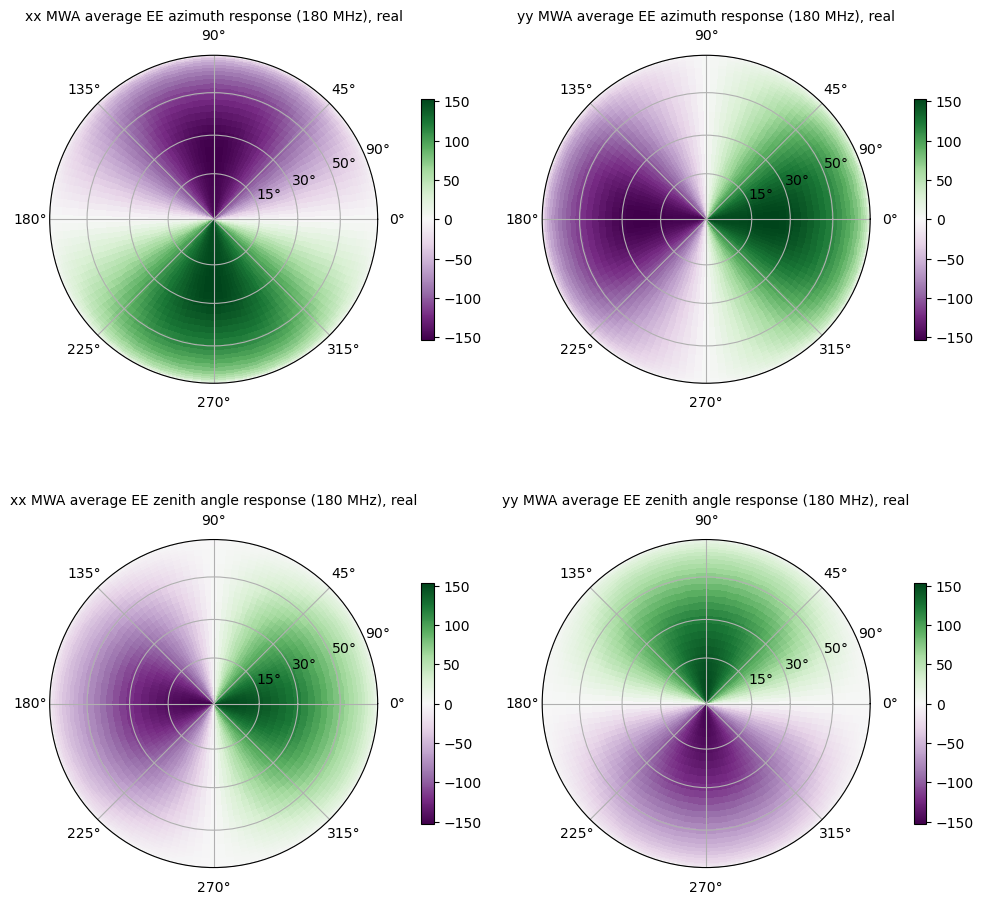

In [7]:
f_ind = 41
plot_beam_arrays(
    beam_vals=aee_dipole_jones[:, :, f_ind],
    az_array=az_array,
    za_array=za_array,
    beam_name="MWA average EE",
    beam_type_label="jones",
    feedpol_label=["xx", "yy"],
    freq_label=freqs[f_ind]
)

In [8]:
n_dipole = 16
x_centers, y_centers = np.meshgrid(np.arange(4)*dipole_spacing, np.arange(4)*dipole_spacing)

In [9]:
x_centers = (x_centers - x_centers.mean()).flatten()
y_centers = (y_centers - y_centers.mean()).flatten()
z_centers = np.zeros(16, dtype=float)

In [10]:
delays_sec = delays * base_delay_sec

In [11]:
coupling = np.zeros((n_freqs, n_dipole * 2, n_dipole * 2), dtype=complex)

with fits.open(zmatrix_file) as zfile:
    # COMMENT Data are 32x32x2 cubes per ext. 1st plane Mag, 2nd plane phase 
    # ordering in Z matrix is 0-15:Y, 16-31:X
    if not len(zfile) == n_freqs:
        raise ValueError("Zmatrix file does not have as the same number of frequencies as Jmatrix file.")
    for fi in range(n_freqs):
        if not np.isclose(zfile[fi].header["freq"], freqs[fi]):
            raise ValueError(f"Zmatrix {fi}th freq does not match Jmatrix file.")
        data = zfile[0].data
        coupling_init = data[0,:,:] * (np.cos(data[1,:,:]) + 1j * np.sin(data[1,:,:]))
        coupling[fi, :n_dipole, :n_dipole] = coupling_init[n_dipole:, n_dipole:]
        coupling[fi, :n_dipole, n_dipole:] = coupling_init[n_dipole:, :n_dipole]
        coupling[fi, n_dipole:, :n_dipole] = coupling_init[:n_dipole, n_dipole:]
        coupling[fi, n_dipole:, n_dipole:] = coupling_init[:n_dipole, :n_dipole]


In [12]:
# this is what FHD does. But by construction it excludes x <-> y coupling
# because rather than a 32 x 32 matrix we have (2 x 16 x 16)
fhd_coupling = np.zeros((2, n_freqs, n_dipole, n_dipole), dtype=complex)
fhd_coupling[0] = coupling[:, :n_dipole, :n_dipole]
fhd_coupling[1] = coupling[:, n_dipole:, n_dipole:]

z_lna = (
    np.interp(freqs, impedance_freq, np.real(dipole_impedance))
    + 1j * np.interp(freqs, impedance_freq, np.imag(dipole_impedance))
)

ztotal = coupling.copy()
fhd_ztotal = fhd_coupling.copy()
for fi in range(n_freqs):
    ztotal[fi] += np.eye(32) * z_lna[fi]
    fhd_ztotal[0, [fi]] += np.eye(16) * z_lna[fi]
    fhd_ztotal[1, [fi]] += np.eye(16) * z_lna[fi]

inv_z = np.linalg.inv(ztotal)

fhd_inv_z = np.linalg.inv(fhd_ztotal)


In [13]:
# calculate delays for dipoles relative to the center of the tile
east_direction_cos = np.sin(za_array) * np.sin(az_array)
north_direction_cos = np.sin(za_array) * np.cos(az_array)
radial_direction_cos = np.cos(za_array)

geometric_dipole_delay = (
    np.outer(east_direction_cos.flatten(), x_centers)
    + np.outer(north_direction_cos.flatten(), y_centers)
    + np.outer(radial_direction_cos.flatten(), z_centers)
)

apparray_factor = np.zeros((2, n_freqs, n_theta, n_phi), dtype=complex)
fhd_apparray_factor = np.zeros((2, n_freqs, n_theta, n_phi), dtype=complex)
for fi, this_f in enumerate(freqs):
    k_conv=(2. * np.pi) * (this_f / constants.c.to("m/s").value) 
    delayline_term = np.exp(1j * 2. * np.pi * delays_sec * this_f * gains)
    
    port_current = np.dot(inv_z[fi], delayline_term.reshape(32)).reshape(2,16)

    for feed_i in range(2):
        fhd_port_current = np.dot(fhd_inv_z[feed_i,fi], delayline_term[feed_i])

        for dip_i in range(n_dipole):
            geometric_dipole_factor = np.exp(-1j * k_conv * geometric_dipole_delay[:, dip_i])
            apparray_factor[feed_i, fi] += (geometric_dipole_factor * port_current[feed_i, dip_i]).reshape((n_theta, n_phi))
            fhd_apparray_factor[feed_i, fi] += (geometric_dipole_factor * fhd_port_current[dip_i]).reshape((n_theta, n_phi))



In [14]:
aee_beam_jones = np.ndarray((2, 2, n_freqs, n_theta, n_phi), dtype=complex)
fhd_aee_beam_jones = np.ndarray((2, 2, n_freqs, n_theta, n_phi), dtype=complex)
for vec_i in range(2):
    aee_beam_jones[vec_i] = aee_dipole_jones[vec_i] * apparray_factor
    fhd_aee_beam_jones[vec_i] = aee_dipole_jones[vec_i] * fhd_apparray_factor

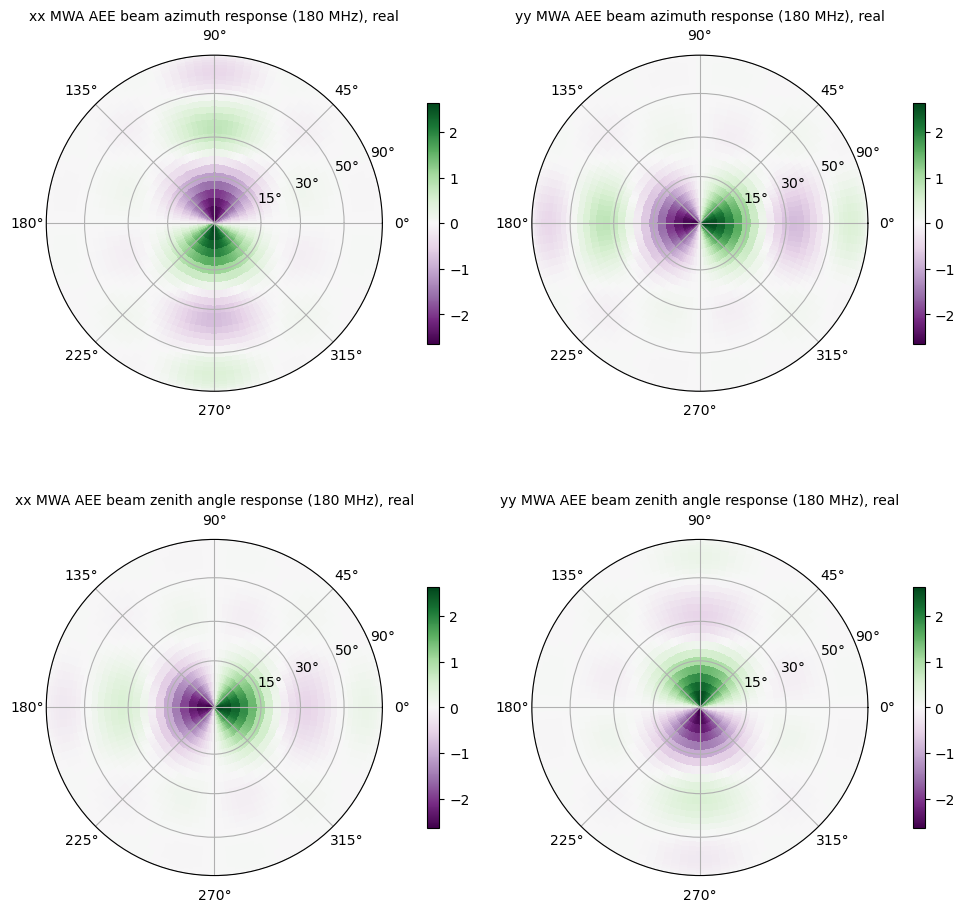

In [15]:
f_ind = 41
plot_beam_arrays(
    beam_vals=aee_beam_jones[:, :, f_ind],
    az_array=az_array,
    za_array=za_array,
    beam_name="MWA AEE beam",
    beam_type_label="jones",
    feedpol_label=["xx", "yy"],
    freq_label=freqs[f_ind]
)

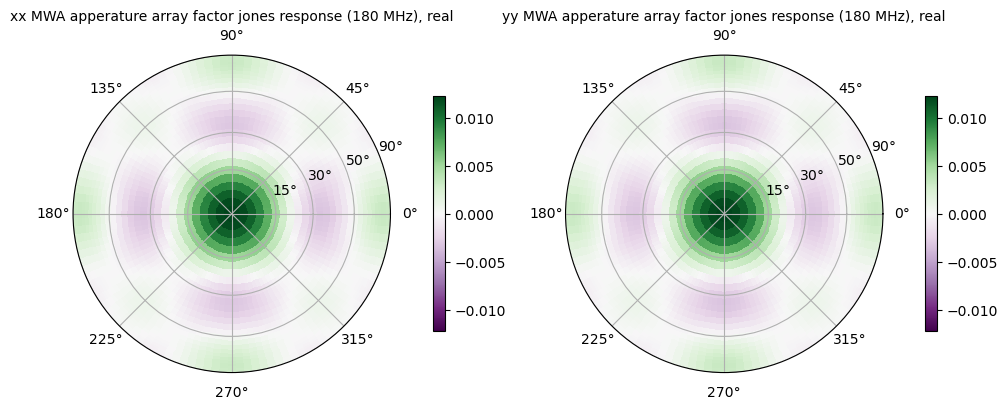

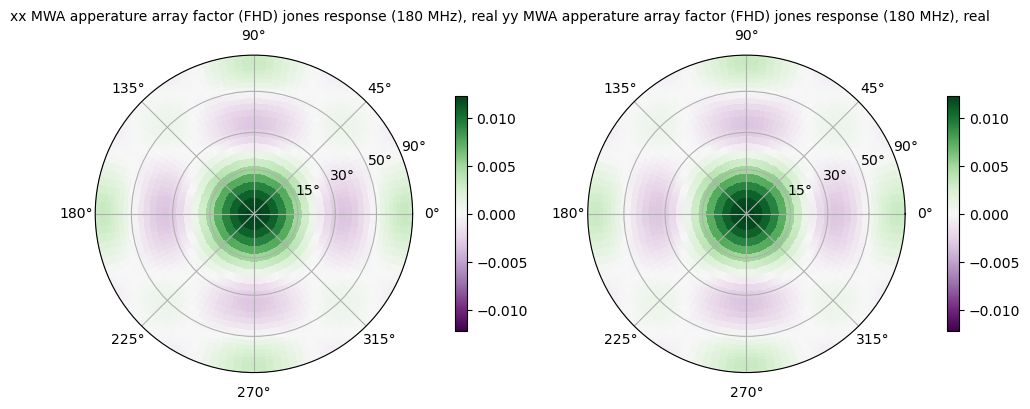

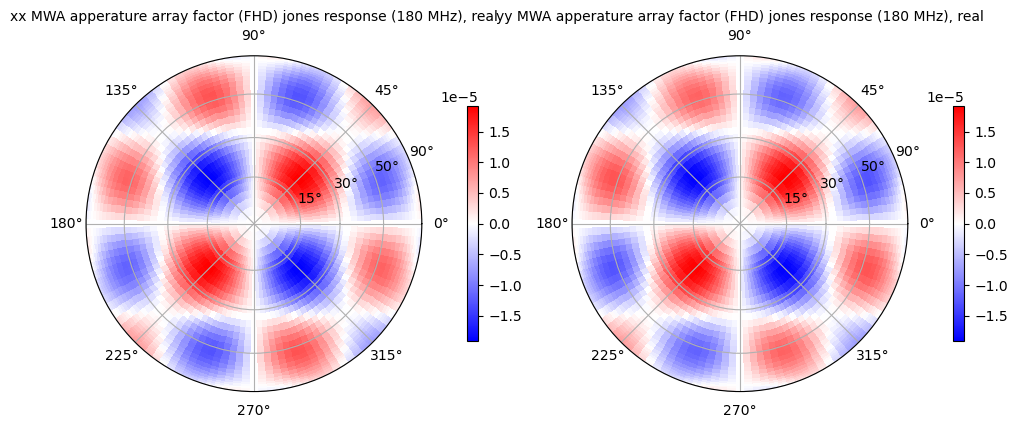

In [16]:
f_ind = 41
plot_beam_arrays(
    beam_vals=apparray_factor[np.newaxis, :, f_ind],
    az_array=az_array,
    za_array=za_array,
    beam_name="MWA apperature array factor",
    beam_type_label="jones",
    feedpol_label=["xx", "yy"],
    freq_label=freqs[f_ind]
)

plot_beam_arrays(
    beam_vals=fhd_apparray_factor[np.newaxis, :, f_ind],
    az_array=az_array,
    za_array=za_array,
    beam_name="MWA apperature array factor (FHD)",
    beam_type_label="jones",
    feedpol_label=["xx", "yy"],
    freq_label=freqs[f_ind]
)

apparray_factor_diff = apparray_factor - fhd_apparray_factor

plot_beam_arrays(
    beam_vals=apparray_factor_diff[np.newaxis, :, f_ind],
    az_array=az_array,
    za_array=za_array,
    beam_name="MWA apperature array factor (FHD)",
    beam_type_label="jones",
    feedpol_label=["xx", "yy"],
    freq_label=freqs[f_ind],
    colormap="bwr"
)

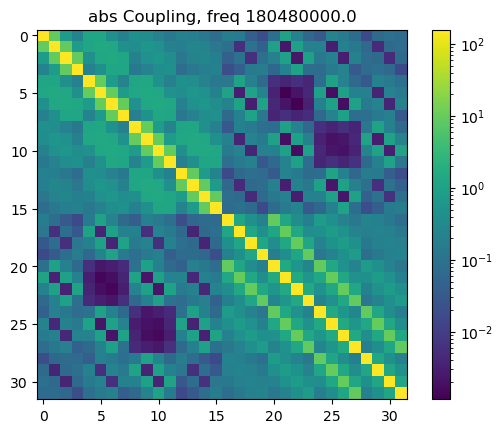

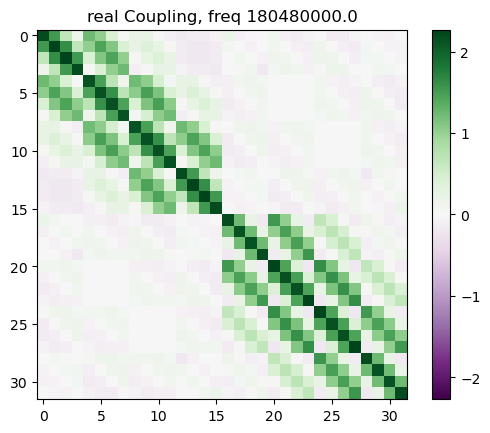

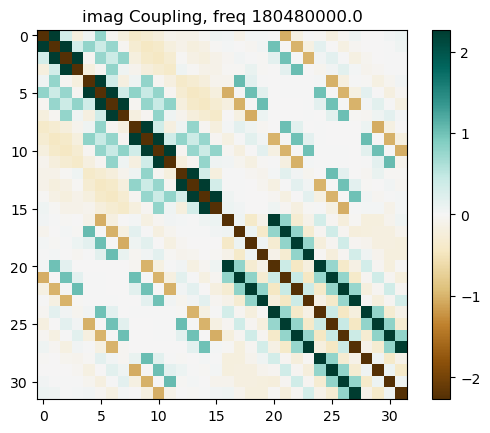

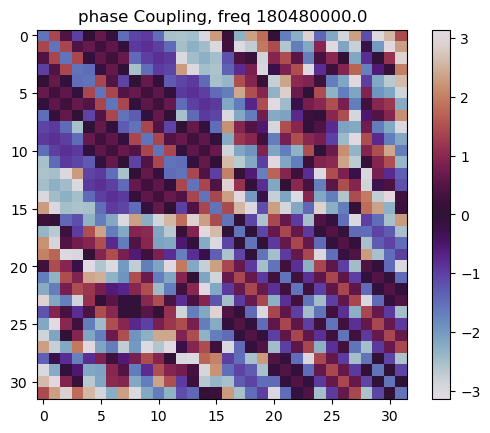

In [17]:
fi = 41
plt.imshow(np.abs(coupling[fi]), norm=LogNorm())
plt.title(f"abs Coupling, freq {freqs[fi]}")
plt.colorbar()
plt.show()
real_max_abs = np.max(np.abs(np.real(coupling[fi])))
plt.imshow(np.real(coupling[fi]), cmap="PRGn", vmax=real_max_abs, vmin=-1*real_max_abs)
plt.title(f"real Coupling, freq {freqs[fi]}")
plt.colorbar()
plt.show()
imag_max_abs = np.max(np.abs(np.imag(coupling[fi])))
plt.imshow(np.imag(coupling[fi]), cmap="BrBG", vmax=real_max_abs, vmin=-1*real_max_abs)
plt.title(f"imag Coupling, freq {freqs[fi]}")
plt.colorbar()
plt.show()
plt.imshow(np.angle(coupling[fi]), cmap="twilight", vmax=np.pi, vmin=-np.pi)
plt.title(f"phase Coupling, freq {freqs[fi]}")
plt.colorbar()
plt.show()

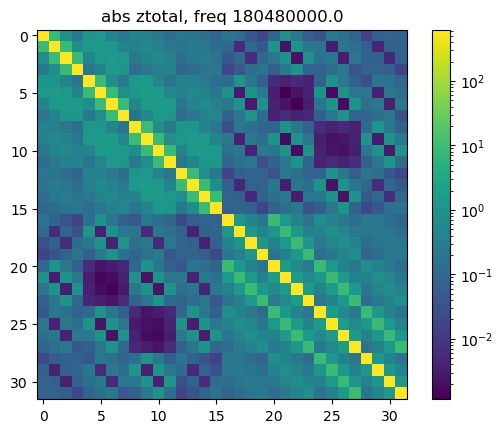

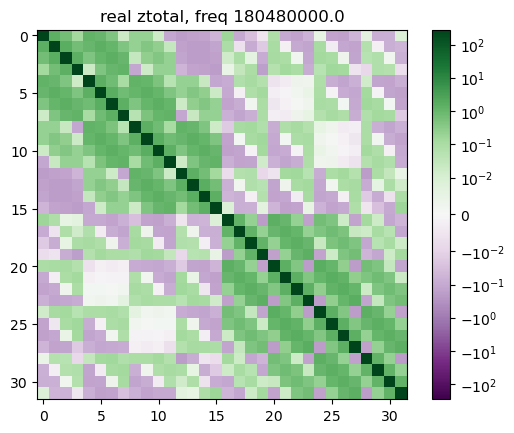

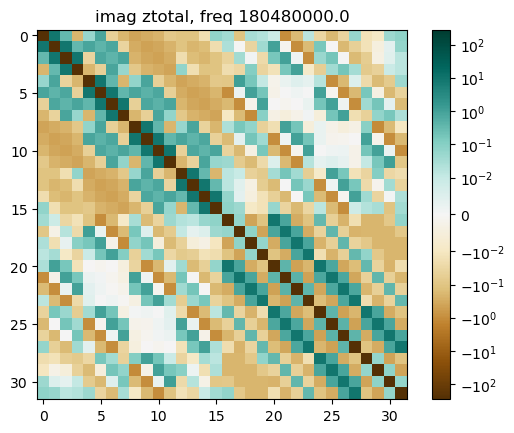

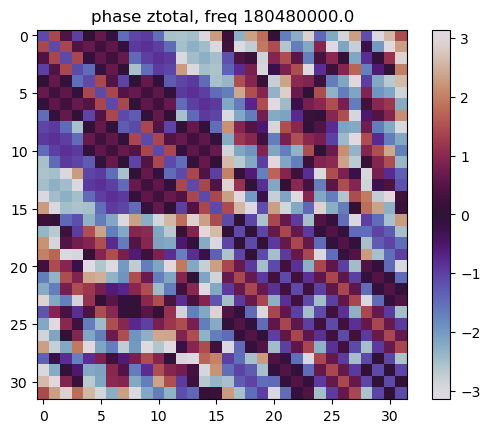

In [18]:
fi = 41
plt.imshow(np.abs(ztotal[fi]), norm=LogNorm())
plt.title(f"abs ztotal, freq {freqs[fi]}")
plt.colorbar()
plt.show()
real_max_abs = np.max(np.abs(np.real(ztotal[fi])))
plt.imshow(
    np.real(ztotal[fi]),
    cmap="PRGn",
    norm=SymLogNorm(vmax=real_max_abs, vmin=-1*real_max_abs, linthresh=1e-2),
)
plt.title(f"real ztotal, freq {freqs[fi]}")
plt.colorbar()
plt.show()
imag_max_abs = np.max(np.abs(np.imag(ztotal[fi])))
plt.imshow(
    np.imag(ztotal[fi]),
    cmap="BrBG",
    norm=SymLogNorm(vmax=real_max_abs, vmin=-1*real_max_abs, linthresh=1e-2),
)
plt.title(f"imag ztotal, freq {freqs[fi]}")
plt.colorbar()
plt.show()
plt.imshow(np.angle(ztotal[fi]), cmap="twilight", vmax=np.pi, vmin=-np.pi)
plt.title(f"phase ztotal, freq {freqs[fi]}")
plt.colorbar()
plt.show()

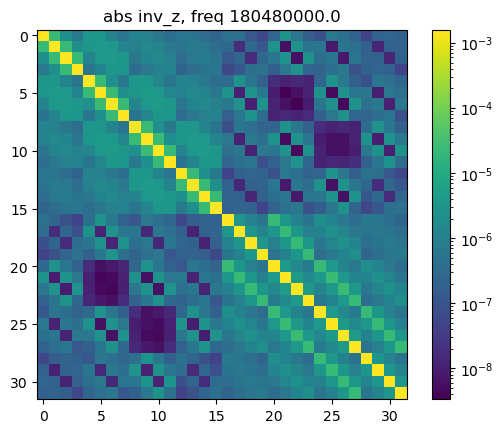

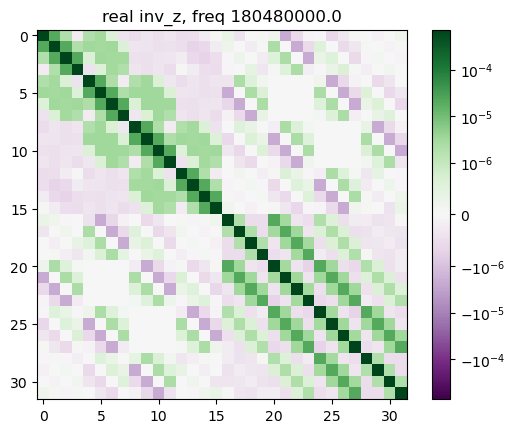

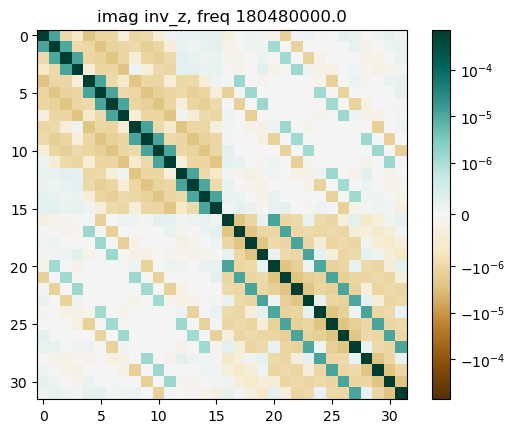

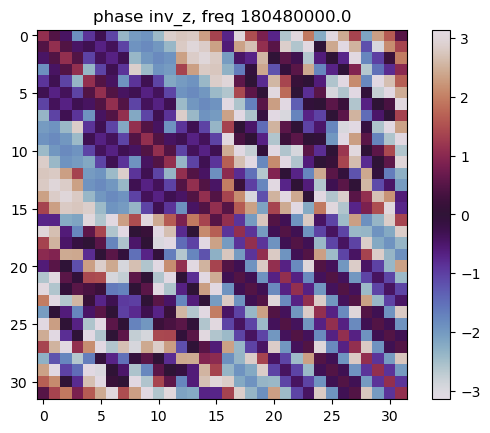

In [19]:
fi = 41
plt.imshow(np.abs(inv_z[fi]), norm=LogNorm())
plt.title(f"abs inv_z, freq {freqs[fi]}")
plt.colorbar()
plt.show()
real_max_abs = np.max(np.abs(np.real(inv_z[fi])))
plt.imshow(
    np.real(inv_z[fi]),
    cmap="PRGn",
    norm=SymLogNorm(vmax=real_max_abs, vmin=-1*real_max_abs, linthresh=1e-6),
)
plt.title(f"real inv_z, freq {freqs[fi]}")
plt.colorbar()
plt.show()
imag_max_abs = np.max(np.abs(np.imag(inv_z[fi])))
plt.imshow(
    np.imag(inv_z[fi]),
    cmap="BrBG",
    norm=SymLogNorm(vmax=real_max_abs, vmin=-1*real_max_abs, linthresh=1e-6),
)
plt.title(f"imag inv_z, freq {freqs[fi]}")
plt.colorbar()
plt.show()
plt.imshow(np.angle(inv_z[fi]), cmap="twilight", vmax=np.pi, vmin=-np.pi)
plt.title(f"phase inv_z, freq {freqs[fi]}")
plt.colorbar()
plt.show()

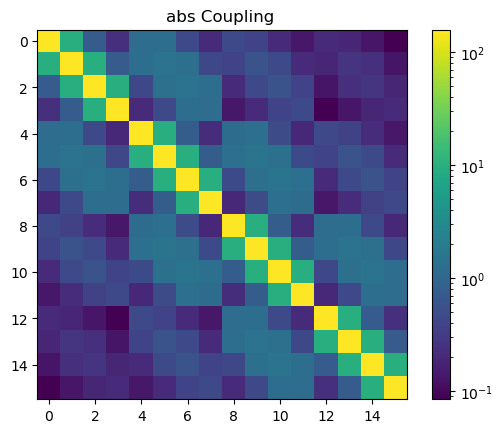

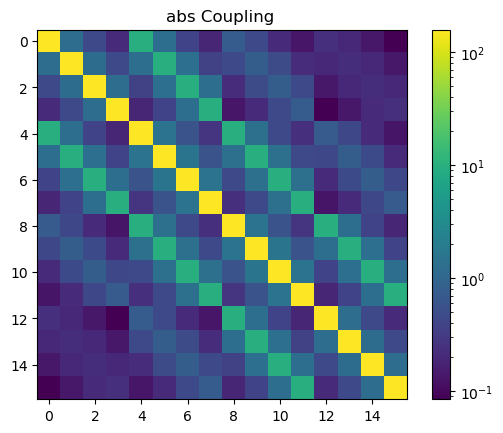

In [20]:
plt.imshow(np.abs(fhd_coupling[0, 0]), norm=LogNorm())
plt.title("abs Coupling ")
plt.colorbar()
plt.show()
plt.imshow(np.abs(fhd_coupling[1, 0]), norm=LogNorm())
plt.title("abs Coupling ")
plt.colorbar()
plt.show()

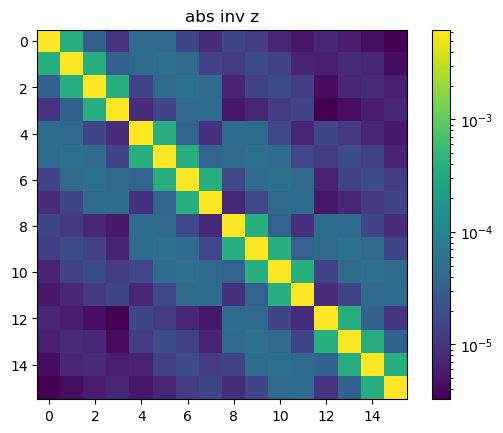

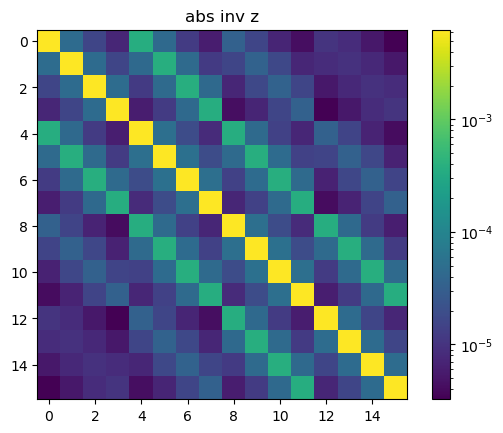

In [21]:
plt.imshow(np.abs(fhd_inv_z[0, 0]), norm=LogNorm())
plt.title("abs inv z")
plt.colorbar()
plt.show()
plt.imshow(np.abs(fhd_inv_z[1, 0]), norm=LogNorm())
plt.title("abs inv z")
plt.colorbar()
plt.show()

In [22]:
np.min(np.abs(coupling[0]))

np.float64(0.0011542226433814483)

In [23]:
np.min(np.abs(fhd_coupling[:,0]))

np.float64(0.08460992312741528)

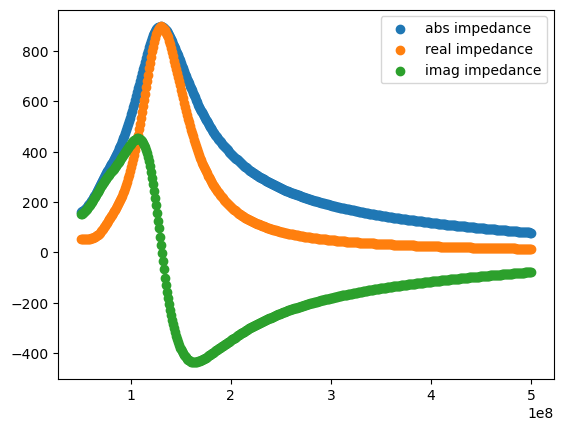

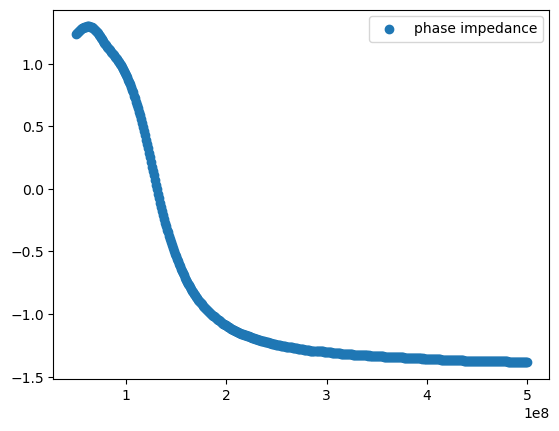

In [24]:
plt.scatter(impedance_freq, np.abs(dipole_impedance), label="abs impedance")
plt.scatter(impedance_freq, np.real(dipole_impedance), label="real impedance")
plt.scatter(impedance_freq, np.imag(dipole_impedance), label="imag impedance")
plt.legend()
plt.show()
plt.scatter(impedance_freq, np.angle(dipole_impedance), label="phase impedance")
plt.legend()
plt.show()

<Axes: xlabel='frequency_Hz', ylabel='Impedance_imag'>

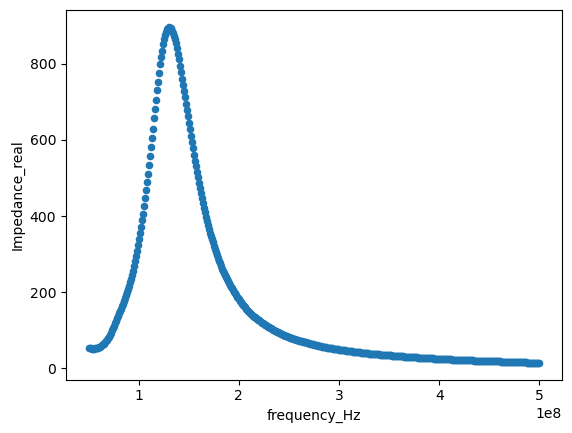

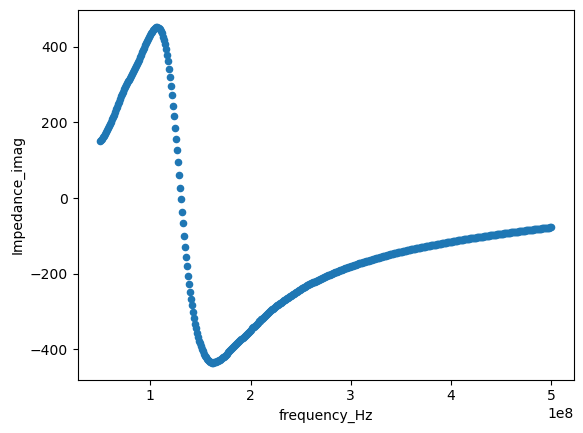

In [25]:
cols = df.columns
df.plot.scatter(x=cols[0], y=cols[1])
df.plot.scatter(x=cols[0], y=cols[2])

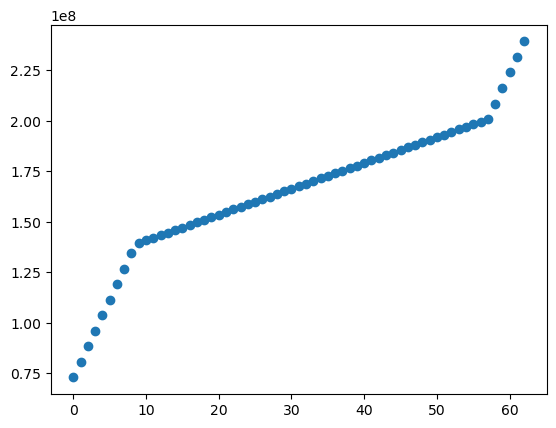

In [26]:
plt.scatter(np.arange(n_freqs), freqs)

In [27]:
freq_diffs = np.diff(freqs)
freq_diffs

array([7680000., 7680000., 7680000., 7680000., 7680000., 7680000.,
       7680000., 7680000., 5120000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 7680000., 7680000., 7680000.,
       7680000., 7680000.])

In [28]:
np.diff(freqs[8:59])

array([5120000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 7680000.])

In [29]:
np.diff(freqs[9:58])

array([1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.,
       1280000., 1280000., 1280000., 1280000., 1280000., 1280000.])

In [30]:
print(freqs[9], freqs[57].max())

139520000.0 200960000.0


In [31]:
print(freqs[8], freqs[58])

134400000.0 208640000.0


In [32]:
test_freqs = freqs[np.asarray([17, 29, 41])]
test_freqs/1e6

array([149.76, 165.12, 180.48])

In [33]:
29 - 17

12